# escape.stream — pipeline offload proof of concept (`to_pipeline_server`)

This notebook walks through offloading a live `escape.stream` computation onto
PSI's **cam_server pipeline server**, running right next to the data source
instead of in this client — the idea behind the not-yet-built
`Stream.to_pipeline_server(name=...)`.

It reproduces, step by step, a real end-to-end test that was run interactively
against the live Bernina cam_server (real channels, real running pipeline
instances, real teardown) — this notebook is the "for me to understand"
write-up of that session, not a new untested design.

**Parts 1–5 below are explanation** — they build the pipeline script by hand
to show exactly what's going on and why. **`Stream.to_pipeline_server()`
now exists for real** (also tested live, same result) and does all of that
in one call — see **Part 6** at the end if you just want the short version.

**What it offloads:**
```python
isref = evtset_stream.element(5)          # a boolean reference-shot marker
ratio = i[~isref] / i[isref].running_mean(N_acc=5)
```
i.e. "normalize each *signal* shot's intensity by the running mean intensity
of the last 5 *reference* shots" — a common pump-probe/reference-normalization
pattern.


## Prerequisites

- A SOCKS tunnel into the PSI network, e.g.:
  ```
  ssh -D 8787 -N your_user@saresb-cons-05
  ```
  (see `escape/stream/dev_proxy.py` — this notebook is off-network-safe by
  design *only* if you don't run the "live" cells below without one; the
  parts that talk to the real dispatcher/cam_server will just fail cleanly
  without it, not partially misbehave.)
- `cam_server` installed in this environment (`pip show cam_server`) — it
  provides `PipelineClient`, the REST client for cam_server's `/api/v1/pipeline`
  endpoints.
- **This talks to real, shared beamline infrastructure.** Every cell that
  creates a pipeline instance uses a name prefixed `test_<something>` and is
  paired with a teardown cell later in the notebook — run them in order, and
  don't leave the "create instance" cell running unattended without following
  through to "stop instance". If you interrupt this notebook partway through,
  jump straight to the **Part 5 — clean up** cell to check nothing was left
  running.


In [1]:
import sys, os, time
from _devpath import prepend_local_checkout_to_path
prepend_local_checkout_to_path()

import numpy as np
import matplotlib.pyplot as plt

# Route escape.stream's HTTP + ZMQ traffic through the SOCKS tunnel above.
# Safe to skip/comment out if you're already on the PSI network directly.
from escape.stream.dev_proxy import enable_socks_proxy
enable_socks_proxy(port=8787)


escape.stream.dev_proxy: routing HTTP + ZMQ traffic through socks5h://127.0.0.1:8787


## Part 1 — the `escape.stream` expression we want to offload

First, build it for real against the live dispatcher, exactly as you would
for any other interactive `escape.stream` analysis — this is the "client-side
truth" the pipeline script below has to reproduce.


In [2]:
from escape.stream import EventWorker, Stream, DataHubEventHandler

ew = EventWorker(DataHubEventHandler(backend='bsread'), make_default=True)

# Stream.from_dispatcher(name, ew) is Stream(name, ew) by another name --
# see its docstring. Used explicitly here for symmetry with Stream.from_tcp()
# in Part 6, where the distinction (dispatcher channel name vs. raw address)
# actually matters.
i = Stream.from_dispatcher('SAROP21-PBPS133:INTENSITY', ew, unit='a.u.')
evtset = Stream.from_dispatcher('SAR-CVME-TIFALL5:EvtSet', ew)

isref = evtset.element(5)   # a new Stream: evtset's value at index 5, per event
i, isref


EventWorker registered as module default.


(Stream('SAROP21-PBPS133:INTENSITY', unit='a.u.', n=0),
 Stream('SAR-CVME-TIFALL5:EvtSet[5]', unit='a.u.', n=0))

In [3]:
ratio = i[~isref] / i[isref].running_mean(N_acc=5)
ratio


Stream('(SAROP21-PBPS133:INTENSITY[(not SAR-CVME-TIFALL5:EvtSet[5])] / SAROP21-PBPS133:INTENSITY[SAR-CVME-TIFALL5:EvtSet[5]]_running_mean)', unit='(a.u. / a.u.)', n=0)

### The computation graph behind `ratio`

This is exactly the graph `escape.stream.graph.build_graph()` was built for —
walking `ratio`'s `ProcObj`/`_source` chain shows every real channel, constant,
and operation it depends on, which is also precisely the information a
`to_pipeline_server()` implementation would need: the channel list to wire
into `bsread_channels`, and (for the parts simple enough to auto-translate)
the operations to reproduce server-side.


        op  (SAROP21-PBPS133:INTENSITY[(not SAR-CVME-TIFALL5:EvtSet[5])] / SAROP21-PBPS133:INTENSITY[SAR-CVME-TIFALL5:EvtSet[5]]_running_mean)
    filter  SAROP21-PBPS133:INTENSITY[(not SAR-CVME-TIFALL5:EvtSet[5])]
   channel  SAROP21-PBPS133:INTENSITY
        op  (not SAR-CVME-TIFALL5:EvtSet[5])
        op  SAR-CVME-TIFALL5:EvtSet[5]
   channel  SAR-CVME-TIFALL5:EvtSet
  constant  5
        op  running_mean(N_acc=5)
    filter  SAROP21-PBPS133:INTENSITY[SAR-CVME-TIFALL5:EvtSet[5]]


<Axes: >

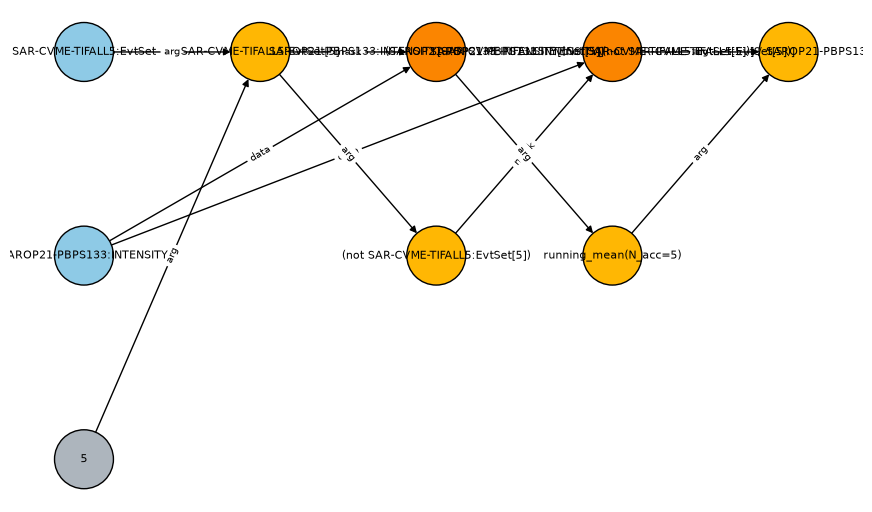

In [4]:
from escape.stream import build_graph, draw_graph  # requires the optional `networkx` package

g = build_graph(ratio)
for n, d in g.nodes(data=True):
    print(f"{d.get('kind'):>10}  {d.get('label')}")
draw_graph(g)


## Part 2 — why this needs real code on the server side

`ratio` isn't source text, it's a live graph of Python objects — some of
which are *stateful* (`running_mean`'s window) and only make sense in
`escape.stream`'s live, event-by-event push model. There's no automatic
translation for that part (yet) — see the design discussion this notebook
comes out of. What *is* mechanical is figuring out **which real channels**
the graph depends on (`i` and `evtset`) and the **contract** the server
expects.

| `escape.stream` (client-side) | cam_server `pipeline_type: "stream"` script (server-side) |
|---|---|
| `Stream('CHANNEL', ew)` | subscribed via `bsread_channels: ["CHANNEL", ...]` in the instance config |
| `evtset.element(5)` | `data["SAR-CVME-TIFALL5:EvtSet"][5]` inside `process()` |
| `i[~isref]` / `i[isref]` (opposite masks) | an `if isref: ... else: ...` branch |
| `i[isref].running_mean(N_acc=5)`'s live deque (held across events where the mask is False) | an explicit **module-level** `deque(maxlen=5)` — `process()` gets no `init`/state argument of its own for `pipeline_type="stream"`, unlike `"custom"` |
| a `ProcObj` returning nothing for an event (an operand was `None`) | `process()` returning `None` — cam_server's `send_data()` then simply doesn't publish for that event |
| the pulse ID / timestamp `escape.stream` tags each sample with | supplied automatically as `process(data, pulse_id, timestamp, parameters)`'s 2nd/3rd args — **only** for `pipeline_type="stream"`; `"custom"` gets neither and would have to open its own bsread subscription |

That table is the actual, verified contract (read from `cam_server`'s own
source, `cam_server/pipeline/types/stream.py` and `.../utils.py`), not
documentation-as-guessed.

The script below is **hand-written** to that contract, for explanation.
`escape.stream.pipeline_codegen.generate_process_script()` now generates the
same thing mechanically by walking `ratio`'s graph from Part 1 — see Part 6.


In [5]:
PIPELINE_SCRIPT = '''\
"""to_pipeline_server example: i[~isref] / i[isref].running_mean(N_acc=5)

isref = element 5 of SAR-CVME-TIFALL5:EvtSet (reference-shot marker).

Mirrors escape.stream's live semantics exactly: the running mean only
updates on reference shots (module-level state persists across process()
calls -- the server-side equivalent of _RunningStat's live deque, since
pipeline_type=\'stream\' gives process() no init/state argument of its own);
the ratio is only emitted on non-reference (signal) shots, using the *held*
mean from the most recent reference shots -- same as ProcObj holding
ret_values across events where an operand\'s FilteredEventSource yields None.
Returning None here means no message is published for that event (see
cam_server.pipeline.utils.send_data), matching "no update this event".
"""
from collections import deque

ISREF_INDEX = 5
N_ACC = 5

_ref_window = deque(maxlen=N_ACC)


def process(data, pulse_id, timestamp, parameters):
    intensity = data.get("SAROP21-PBPS133:INTENSITY")
    evtset = data.get("SAR-CVME-TIFALL5:EvtSet")
    if intensity is None or evtset is None:
        return None

    isref = bool(evtset[ISREF_INDEX])

    if isref:
        _ref_window.append(intensity)
        return None  # i[~isref]: no value on reference shots

    if not _ref_window:
        return None  # denominator undefined until the first reference shot

    ref_mean = sum(_ref_window) / len(_ref_window)
    return {"ratio": intensity / ref_mean, "ref_mean": ref_mean, "n_ref": len(_ref_window)}
'''

script_path = 'test_lemke_h_ratio_notebook.py'
with open(script_path, 'w') as f:
    f.write(PIPELINE_SCRIPT)
print(PIPELINE_SCRIPT)


"""to_pipeline_server example: i[~isref] / i[isref].running_mean(N_acc=5)

isref = element 5 of SAR-CVME-TIFALL5:EvtSet (reference-shot marker).

Mirrors escape.stream's live semantics exactly: the running mean only
updates on reference shots (module-level state persists across process()
calls -- the server-side equivalent of _RunningStat's live deque, since
pipeline_type='stream' gives process() no init/state argument of its own);
the ratio is only emitted on non-reference (signal) shots, using the *held*
mean from the most recent reference shots -- same as ProcObj holding
ret_values across events where an operand's FilteredEventSource yields None.
Returning None here means no message is published for that event (see
cam_server.pipeline.utils.send_data), matching "no update this event".
"""
from collections import deque

ISREF_INDEX = 5
N_ACC = 5

_ref_window = deque(maxlen=N_ACC)


def process(data, pulse_id, timestamp, parameters):
    intensity = data.get("SAROP21-PBPS133:INTENSITY

## Part 3 — upload and create the pipeline instance

`pipeline_type: "stream"` (not `"custom"`) is what auto-subscribes to
`bsread_channels` and hands `process()` the per-event data/pulse_id/timestamp
automatically — see the mapping table above.


In [6]:
from cam_server import PipelineClient

pc = PipelineClient()
print('cam_server version:', pc.get_version())   # sanity check the tunnel + server are reachable


cam_server version: 5.8.1


In [7]:
instance_id = 'test_lemke_h_ratio_notebook'

# already-running instance under this name? better to know before creating another.
assert instance_id not in pc.get_server_info()['active_instances'], \
    f'{instance_id!r} is already running -- stop it first (see Part 5) before re-creating it.'

pc.upload_user_script(script_path)   # NB: returns None -- cam_server_client quirk, not an error
script_name = os.path.basename(script_path)

config = {
    'pipeline_type': 'stream',
    'function': script_name,
    'bsread_channels': ['SAROP21-PBPS133:INTENSITY', 'SAR-CVME-TIFALL5:EvtSet'],
}
iid, stream_address = pc.create_instance_from_config(config, instance_id=instance_id)
print('created:', iid, stream_address)


created: test_lemke_h_ratio_notebook tcp://sf-daqsync-09.psi.ch:11162


## Part 4 — read the result back

The output is a plain bsread stream at a raw `tcp://host:port` address (not a
dispatcher-registered channel name) — connect to it directly with
`bsread.Source(host=..., port=...)`.

The facility's reference-shot cadence (`EvtSet[5]`) turned out to be a clean
1-in-100 pulses when this was tested live — `ref_mean` should visibly step
every ~100 events below, holding steady in between.


In [8]:
from cam_server_client.utils import get_host_port_from_stream_address
from bsread import Source, SUB

host, port = get_host_port_from_stream_address(stream_address)

n_events = 500
pulse_ids, ratios, ref_means, n_refs = [], [], [], []

with Source(host=host, port=port, mode=SUB, receive_timeout=5000) as s:
    while len(pulse_ids) < n_events:
        m = s.receive()
        if m is None or m.data is None or not m.data.data:
            print(f'timed out waiting for a message (got {len(pulse_ids)}/{n_events})')
            break
        row = {k: v.value for k, v in m.data.data.items()}
        pulse_ids.append(m.data.pulse_id)
        ratios.append(row['ratio'])
        ref_means.append(row['ref_mean'])
        n_refs.append(row['n_ref'])

print(f'received {len(pulse_ids)} events')


received 500 events


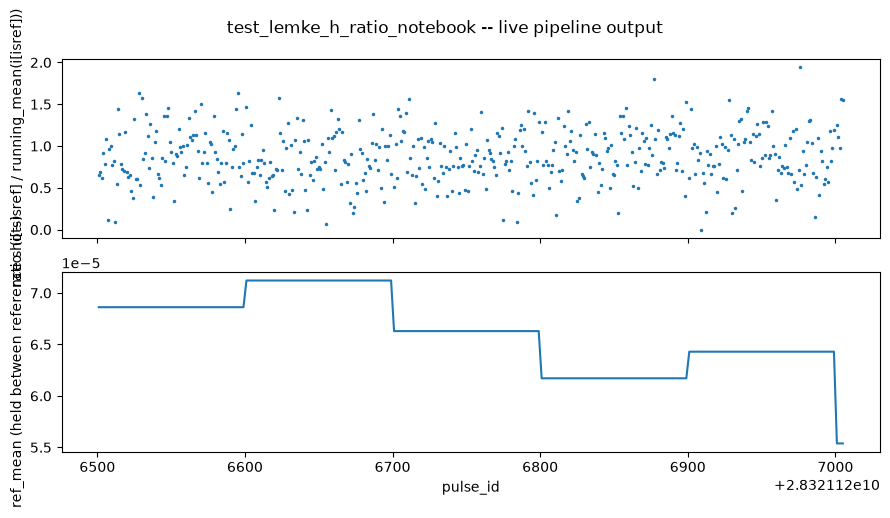

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
ax1.plot(pulse_ids, ratios, '.', ms=3)
ax1.set_ylabel('ratio  (i[~isref] / running_mean(i[isref]))')
ax2.plot(pulse_ids, ref_means, '-')
ax2.set_ylabel('ref_mean (held between reference shots)')
ax2.set_xlabel('pulse_id')
fig.suptitle(f'{instance_id} -- live pipeline output')
fig.tight_layout()


## Part 5 — clean up

Always run this — whether or not the cells above completed, ran into an
error, or you're re-running this notebook from a partial state. It's safe to
run even if nothing is active.


In [10]:
info = pc.get_server_info()
if instance_id in info['active_instances']:
    pc.stop_instance(instance_id)
    print('stopped', instance_id)
else:
    print(instance_id, 'was not running -- nothing to stop')

info = pc.get_server_info()
print('still active?', instance_id in info['active_instances'])


stopped test_lemke_h_ratio_notebook
still active? False


## Part 6 — the real thing: `Stream.to_pipeline_server()`

Everything in Parts 1–5 above — walk the graph for the channel list,
hand-write the equivalent `process()` script, upload it, wire
`bsread_channels`, create the instance, read the output back, tear it down —
is now one method call. It reuses the exact same `ratio` Stream built in
Part 1; no need to rebuild anything.

**Coverage**: real channels, constants, arithmetic operators,
`element()`/indexing, opposite-mask `filter()`/`[mask]` pairs, and the plain
(unweighted, non-nan-skipping) `running_mean`/`running_std`/`running_median`/
`running_mad` family — exactly what Parts 1–5 walked through by hand.
Anything else (`categorize()`/`digitize()`, weighted or nan-skipping running
stats, an unrecognized custom function) raises `NotImplementedError` naming
exactly what's missing, rather than silently deploying code that doesn't
match what the Stream actually computes — see `Stream.to_pipeline_server`'s
own docstring for the full picture, including how to make a custom function
pipeline-compatible via a `_graph_codegen` hook.

Reading the result back also has a real constructor now —
`Stream.from_tcp(address, field)` — instead of hand-rolling a `bsread.Source`
loop like Part 4 did. **Note the one thing it does *not* do**: the pipeline's
output is a raw `tcp://` address, not a dispatcher channel name — it was
never registered with the dispatcher or the databuffer (confirmed live: it
does not show up in `bsread.dispatcher.get_current_channels()`, before or
after creating the instance). `from_tcp()` connects directly to that address
on its own dedicated `EventWorker`; it does not make the stream
dispatcher-discoverable by name, and there's no self-service way to do that
from here — that would need a separate, facility-level registration step
outside `cam_server`'s own API.


In [11]:
instance_id, stream_address = ratio.to_pipeline_server('test_lemke_h_ratio_v2')
print('deployed:', instance_id, stream_address)


deployed: test_lemke_h_ratio_v2 tcp://sf-daqsync-09.psi.ch:11163


received 209 events


Text(0, 0.5, 'ratio (via to_pipeline_server + from_tcp)')

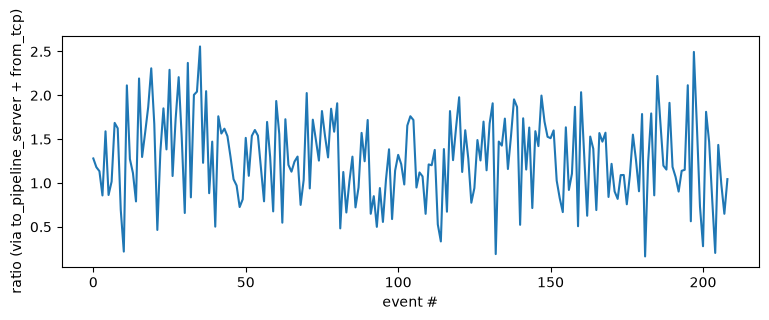

In [12]:
result = Stream.from_tcp(stream_address, instance_id)
result.accumulate(True)

n_events = 200
deadline = time.time() + 30
while len(result) < n_events and time.time() < deadline:
    time.sleep(0.2)
result.accumulate(False)

print(f'received {len(result)} events')
plt.figure(figsize=(9, 3))
plt.plot(result[:])
plt.xlabel('event #'); plt.ylabel('ratio (via to_pipeline_server + from_tcp)')


In [13]:
# Same unconditional cleanup pattern as Part 5 -- always run this.
info = pc.get_server_info()
if instance_id in info['active_instances']:
    pc.stop_instance(instance_id)
    print('stopped', instance_id)
else:
    print(instance_id, 'was not running -- nothing to stop')
print('still active?', instance_id in pc.get_server_info()['active_instances'])


stopped test_lemke_h_ratio_v2
still active? False
